In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, brier_score_loss
from sklearn.model_selection import GridSearchCV
import shap

In [13]:
# ========================================
# LOAD ALL DATA SOURCES
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set path to your data folder
data_path = '/Users/akashvemali/Desktop/Data/'  # CHANGE THIS!

# 1. World Bank Data (Annual)
inflation = pd.read_csv(data_path + 'API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_285.csv', skiprows=4)
gdp_growth = pd.read_csv(data_path + 'API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_57.csv', skiprows=4)
unemployment = pd.read_csv(data_path + 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_33398.csv', skiprows=4)
trade = pd.read_csv(data_path + 'API_NE.TRD.GNFS.ZS_DS2_en_csv_v2_171.csv', skiprows=4)
current_account = pd.read_csv(data_path + 'API_BN.CAB.XOKA.GD.ZS_DS2_en_csv_v2_33256.csv', skiprows=4)

# 2. US-Specific Data (FRED)
us_npl = pd.read_csv(data_path + 'USNP.csv')
us_loans = pd.read_csv(data_path + 'BUSLOANSNSA.csv')
us_gdp = pd.read_csv(data_path + 'GDPC1.csv')

# 3. BIS Credit Gap Data
credit_gap = pd.read_csv(data_path + 'WS_CREDIT_GAP_csv_col.csv')

# 4. Policy Uncertainty Data
brazil_epu = pd.read_csv(data_path + 'Brazil_Policy_Uncertainty_Data.csv')
us_epu = pd.read_csv(data_path + 'US_Policy_Uncertainty_Data.csv')
uk_epu = pd.read_csv(data_path + 'UK_Policy_Uncertainty_Data.csv')
germany_epu = pd.read_csv(data_path + 'Germany_Policy_Uncertainty_Data.csv')
india_epu = pd.read_csv(data_path + 'India_Policy_Uncertainty_Data.csv')
mexico_epu = pd.read_csv(data_path + 'Mexico_Press_Uncertainty_Data.csv')
argentina_epu = pd.read_csv(data_path + 'Argentina_Press_Uncertainty_Data.csv')
chile_epu = pd.read_csv(data_path + 'Chile_Press_Uncertainty_Data.csv')
russia_epu = pd.read_csv(data_path + 'Russia_Policy_Uncertainty_Data.csv')
japan_epu = pd.read_csv(data_path + 'Japan_Policy_Uncertainty_Data.csv')
spain_epu = pd.read_csv(data_path + 'Spain_Policy_Uncertainty_Data.csv')
turkey_epu = pd.read_csv(data_path + 'Turkey_Policy_Uncertainty_Data.csv')



print("✅ All data loaded successfully!")
print(f"\n📊 Data shapes:")
print(f"Inflation: {inflation.shape}")
print(f"GDP Growth: {gdp_growth.shape}")
print(f"Unemployment: {unemployment.shape}")
print(f"Trade: {trade.shape}")
print(f"US NPLs: {us_npl.shape}")
print(f"US Loans: {us_loans.shape}")
print(f"US GDP: {us_gdp.shape}")
print(f"BIS Credit Gap: {credit_gap.shape}")
print(f"Brazil EPU: {brazil_epu.shape}")

✅ All data loaded successfully!

📊 Data shapes:
Inflation: (265, 71)
GDP Growth: (265, 71)
Unemployment: (265, 71)
Trade: (265, 71)
US NPLs: (147, 2)
US Loans: (954, 2)
US GDP: (317, 2)
BIS Credit Gap: (132, 327)
Brazil EPU: (427, 3)


In [14]:
print("📋 BIS FILE COLUMNS:")
print(credit_gap.columns.tolist())

# 2. Check the first few rows
print("\n📋 FIRST 5 ROWS:")
print(credit_gap.head())

# 3. Check what's in TITLE_TS (or similar column)
# Look for a column that identifies the country/series
title_col = [col for col in credit_gap.columns if 'TITLE' in col or 'SERIES' in col or 'BORROWERS' in col]
print(f"\n📋 Columns containing 'TITLE', 'SERIES', or 'BORROWERS':")
print(title_col)

# 4. Check the unique values in the first few columns
print("\n📋 TITLE_TS values (first 10):")
if 'TITLE_TS' in credit_gap.columns:
    print(credit_gap['TITLE_TS'].head(10))
else:
    print("No 'TITLE_TS' column found. Trying 'SERIES'...")
    if 'SERIES' in credit_gap.columns:
        print(credit_gap['SERIES'].head(10))
    else:
        print("Checking first column:", credit_gap.columns[0])
        print(credit_gap[credit_gap.columns[0]].head(10))

📋 BIS FILE COLUMNS:
['FREQ', 'Frequency', 'BORROWERS_CTY', "Borrowers' country", 'TC_BORROWERS', 'Borrowing sector', 'TC_LENDERS', 'Lending sector', 'CG_DTYPE', 'Credit gap data type', 'TIME_FORMAT', 'Time Format', 'TITLE_TS', 'Series', '1947-Q4', '1948-Q1', '1948-Q2', '1948-Q3', '1948-Q4', '1949-Q1', '1949-Q2', '1949-Q3', '1949-Q4', '1950-Q1', '1950-Q2', '1950-Q3', '1950-Q4', '1951-Q1', '1951-Q2', '1951-Q3', '1951-Q4', '1952-Q1', '1952-Q2', '1952-Q3', '1952-Q4', '1953-Q1', '1953-Q2', '1953-Q3', '1953-Q4', '1954-Q1', '1954-Q2', '1954-Q3', '1954-Q4', '1955-Q1', '1955-Q2', '1955-Q3', '1955-Q4', '1956-Q1', '1956-Q2', '1956-Q3', '1956-Q4', '1957-Q1', '1957-Q2', '1957-Q3', '1957-Q4', '1958-Q1', '1958-Q2', '1958-Q3', '1958-Q4', '1959-Q1', '1959-Q2', '1959-Q3', '1959-Q4', '1960-Q1', '1960-Q2', '1960-Q3', '1960-Q4', '1961-Q1', '1961-Q2', '1961-Q3', '1961-Q4', '1962-Q1', '1962-Q2', '1962-Q3', '1962-Q4', '1963-Q1', '1963-Q2', '1963-Q3', '1963-Q4', '1964-Q1', '1964-Q2', '1964-Q3', '1964-Q4', '196

In [15]:
series_col = 'TITLE_TS'

# Check what series are available for your countries
# The BORROWERS_CTY column has country codes
countries_to_check = ['US', 'GB', 'DE', 'BR', 'IN', 'MX','AR','CL','RU','ES','JP','TR']

print("📋 Available series for your countries:\n")

for country in countries_to_check:
    # Filter rows for this country
    country_rows = credit_gap[credit_gap['BORROWERS_CTY'] == country]
    
    if len(country_rows) > 0:
        print(f"\n✅ {country}:")
        # Show the series codes and what type of data they are
        for idx, row in country_rows.iterrows():
            series = row['TITLE_TS']
            data_type = row['CG_DTYPE']  # 'A' = actual, 'C' = gap, 'B' = trend
            desc = row['Credit gap data type'] if 'Credit gap data type' in credit_gap.columns else 'N/A'
            print(f"   {series} (Type: {data_type}) - {desc}")
    else:
        print(f"\n❌ {country}: No data found")

# Also check what the actual BORROWERS_CTY values are
print("\n\n📋 All BORROWERS_CTY values available:")
print(credit_gap['BORROWERS_CTY'].unique())

📋 Available series for your countries:


✅ US:
   nan (Type: A) - Credit-to-GDP ratios (actual data)
   nan (Type: B) - Credit-to-GDP trend (HP filter)
   nan (Type: C) - Credit-to-GDP gaps (actual-trend)

✅ GB:
   nan (Type: A) - Credit-to-GDP ratios (actual data)
   nan (Type: B) - Credit-to-GDP trend (HP filter)
   nan (Type: C) - Credit-to-GDP gaps (actual-trend)

✅ DE:
   nan (Type: A) - Credit-to-GDP ratios (actual data)
   nan (Type: B) - Credit-to-GDP trend (HP filter)
   nan (Type: C) - Credit-to-GDP gaps (actual-trend)

✅ BR:
   nan (Type: A) - Credit-to-GDP ratios (actual data)
   nan (Type: C) - Credit-to-GDP gaps (actual-trend)
   nan (Type: B) - Credit-to-GDP trend (HP filter)

✅ IN:
   nan (Type: A) - Credit-to-GDP ratios (actual data)
   nan (Type: C) - Credit-to-GDP gaps (actual-trend)
   nan (Type: B) - Credit-to-GDP trend (HP filter)

✅ MX:
   nan (Type: A) - Credit-to-GDP ratios (actual data)
   nan (Type: B) - Credit-to-GDP trend (HP filter)
   nan (Type: C) - Cred

In [16]:
# ========================================
# CORRECTED: EXTRACT BIS CREDIT GAP DATA
# ========================================

# Define your countries
countries = ['US', 'GB', 'DE', 'BR','IN', 'MX', 'AR', 'CL','RU','ES','JP','TR']

# Filter for your countries AND gap data (CG_DTYPE == 'C')
# 'C' = Credit-to-GDP gaps (actual-trend)
gap_data = credit_gap[
    (credit_gap['BORROWERS_CTY'].isin(countries)) & 
    (credit_gap['CG_DTYPE'] == 'C')
]

print(f"✅ Filtered gap data shape: {gap_data.shape}")
print(f"\n📋 Countries found: {gap_data['BORROWERS_CTY'].unique()}")
print(f"📋 CG_DTYPE values: {gap_data['CG_DTYPE'].unique()}")

# Get all quarter columns
quarter_cols = [col for col in credit_gap.columns if '-Q' in col]

print(f"\n📋 Number of quarter columns: {len(quarter_cols)}")
print(f"First quarter: {quarter_cols[0]}")
print(f"Last quarter: {quarter_cols[-1]}")

# Melt from wide to long
gap_long = pd.melt(
    gap_data,
    id_vars=['BORROWERS_CTY', 'CG_DTYPE'],
    value_vars=quarter_cols,
    var_name='quarter',
    value_name='credit_gap'
)

# Drop rows with missing values
gap_long = gap_long.dropna(subset=['credit_gap'])

# Rename country column
gap_long = gap_long.rename(columns={'BORROWERS_CTY': 'country_code'})

# Convert quarter to date
gap_long['date'] = pd.to_datetime(gap_long['quarter'].str.replace('-Q', '-'))

# Extract year and quarter
gap_long['year'] = gap_long['date'].dt.year
gap_long['quarter_num'] = gap_long['date'].dt.quarter

print("\n✅ BIS credit gap data extracted successfully!")
print(f"📊 Shape: {gap_long.shape}")
print(f"\n📋 Countries: {gap_long['country_code'].unique()}")
print(f"📅 Date range: {gap_long['date'].min()} to {gap_long['date'].max()}")
print(f"\n📋 First 10 rows:")
print(gap_long[['country_code', 'quarter', 'credit_gap']].head(10))

# Save the extracted data
gap_long.to_csv(data_path + 'bis_credit_gap_extracted.csv', index=False)
print("\n✅ Saved to 'bis_credit_gap_extracted.csv'")

✅ Filtered gap data shape: (12, 327)

📋 Countries found: <StringArray>
['MX', 'JP', 'DE', 'AR', 'US', 'ES', 'GB', 'TR', 'IN', 'BR', 'RU', 'CL']
Length: 12, dtype: str
📋 CG_DTYPE values: <StringArray>
['C']
Length: 1, dtype: str

📋 Number of quarter columns: 313
First quarter: 1947-Q4
Last quarter: 2025-Q4

✅ BIS credit gap data extracted successfully!
📊 Shape: (2035, 7)

📋 Countries: <StringArray>
['US', 'IN', 'DE', 'GB', 'JP', 'ES', 'MX', 'CL', 'AR', 'TR', 'RU', 'BR']
Length: 12, dtype: str
📅 Date range: 1957-04-01 00:00:00 to 2025-04-01 00:00:00

📋 First 10 rows:
    country_code  quarter  credit_gap
484           US  1957-Q4      0.7754
496           US  1958-Q1      0.5234
508           US  1958-Q2      1.0925
520           US  1958-Q3      1.3479
532           US  1958-Q4      1.8237
544           US  1959-Q1      0.5392
556           US  1959-Q2      0.5547
568           US  1959-Q3      0.2539
580           US  1959-Q4      0.7242
592           US  1960-Q1     -0.1927

✅ Saved t

In [17]:
# ========================================
# INSPECT YOUR DATA
# ========================================

# Check World Bank data structure
print("📋 World Bank Data Columns:")
print(inflation.columns.tolist()[:10])
print("\n📋 Countries available:")
print(inflation['Country Name'].unique()[:10])
print(f"\n📋 Total countries: {len(inflation['Country Name'].unique())}")

# Check date range
year_cols = [col for col in inflation.columns if col.isdigit()]
print(f"\n📅 Year range: {min(year_cols)} to {max(year_cols)}")

# Check US NPLs
print(f"\n📋 US NPLs date range:")
print(f"Start: {us_npl['observation_date'].min()}")
print(f"End: {us_npl['observation_date'].max()}")

# Check BIS Credit Gap - see what countries are available
print(f"\n📋 BIS Credit Gap - Series available:")
print(credit_gap['TITLE_TS'].unique()[:20])

📋 World Bank Data Columns:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965']

📋 Countries available:
<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina']
Length: 10, dtype: str

📋 Total countries: 265

📅 Year range: 1960 to 2025

📋 US NPLs date range:
Start: 1984-01-01
End: 2020-07-01

📋 BIS Credit Gap - Series available:
[nan]


In [18]:
try:
    print(f"✅ gap_long exists!")
    print(f"   Shape: {gap_long.shape}")
    print(f"   Countries: {gap_long['country_code'].unique()}")
    print(f"   Date range: {gap_long['date'].min()} to {gap_long['date'].max()}")
    print(f"\n   First 5 rows:")
    print(gap_long[['country_code', 'date', 'credit_gap']].head())
except NameError:
    print("❌ gap_long does not exist. Please run the extraction code again.")

✅ gap_long exists!
   Shape: (2035, 7)
   Countries: <StringArray>
['US', 'IN', 'DE', 'GB', 'JP', 'ES', 'MX', 'CL', 'AR', 'TR', 'RU', 'BR']
Length: 12, dtype: str
   Date range: 1957-04-01 00:00:00 to 2025-04-01 00:00:00

   First 5 rows:
    country_code       date  credit_gap
484           US 1957-04-01      0.7754
496           US 1958-01-01      0.5234
508           US 1958-02-01      1.0925
520           US 1958-03-01      1.3479
532           US 1958-04-01      1.8237


In [19]:
# ========================================
# STEP 1: FIXED RESHAPE FUNCTION
# ========================================

def reshape_wb_data(df, indicator_name):
    """
    Convert World Bank wide format to long format.
    """
    # The column names are exactly as in your data
    country_col = 'Country Name'
    code_col = 'Country Code'
    
    # Get year columns (all columns that are digits)
    year_cols = [col for col in df.columns if str(col).isdigit()]
    
    print(f"✅ Reshaping {indicator_name}...")
    print(f"   Found {len(year_cols)} year columns")
    
    # Melt the data
    df_long = pd.melt(
        df,
        id_vars=[country_col, code_col],
        value_vars=year_cols,
        var_name='year',
        value_name=indicator_name
    )
    
    # Convert year to integer
    df_long['year'] = df_long['year'].astype(int)
    
    # Drop rows with missing values
    df_long = df_long.dropna(subset=[indicator_name])
    
    # Keep only the columns we need
    df_long = df_long[['Country Code', 'year', indicator_name]]
    
    print(f"   Shape: {df_long.shape}")
    
    return df_long

# Reshape each indicator
gdp_long = reshape_wb_data(gdp_growth, 'gdp_growth')
inflation_long = reshape_wb_data(inflation, 'inflation')
unemployment_long = reshape_wb_data(unemployment, 'unemployment')
trade_long = reshape_wb_data(trade, 'trade_gdp')
ca_long = reshape_wb_data(current_account, 'current_account_gdp')

print("\n✅ All World Bank data reshaped!")

✅ Reshaping gdp_growth...
   Found 66 year columns
   Shape: (14323, 3)
✅ Reshaping inflation...
   Found 66 year columns
   Shape: (11472, 3)
✅ Reshaping unemployment...
   Found 66 year columns
   Shape: (8176, 3)
✅ Reshaping trade_gdp...
   Found 66 year columns
   Shape: (11218, 3)
✅ Reshaping current_account_gdp...
   Found 66 year columns
   Shape: (7715, 3)

✅ All World Bank data reshaped!


In [20]:
# ========================================
# STEP 2: CREATE PANEL (ALL COUNTRIES FIRST)
# ========================================

# Start with GDP
panel = gdp_long.copy()

# Merge other indicators
panel = panel.merge(inflation_long, on=['Country Code', 'year'], how='left')
panel = panel.merge(unemployment_long, on=['Country Code', 'year'], how='left')
panel = panel.merge(trade_long, on=['Country Code', 'year'], how='left')
panel = panel.merge(ca_long, on=['Country Code', 'year'], how='left')

print(f"✅ Panel created with all countries!")
print(f"Shape: {panel.shape}")
print(f"Countries: {panel['Country Code'].nunique()}")

# Filter to your countries
countries = ['USA', 'GBR', 'DEU', 'BRA', 'IND', 'MEX', 'ARG', 'CHL','JPN','RUS','ESP','TUR']
panel = panel[panel['Country Code'].isin(countries)]

# Sort
panel = panel.sort_values(['Country Code', 'year']).reset_index(drop=True)

print(f"\n✅ Panel filtered to your countries!")
print(f"Shape: {panel.shape}")
print(f"Countries: {panel['Country Code'].unique()}")
print(f"Years: {panel['year'].min()} to {panel['year'].max()}")

print(f"\n📋 First 10 rows:")
print(panel.head(10))

# Check if we have data
print(f"\n📋 Summary by country:")
print(panel.groupby('Country Code')['gdp_growth'].count())

✅ Panel created with all countries!
Shape: (14323, 7)
Countries: 261

✅ Panel filtered to your countries!
Shape: (751, 7)
Countries: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR',
 'USA']
Length: 12, dtype: str
Years: 1961 to 2025

📋 First 10 rows:
  Country Code  year  gdp_growth  inflation  unemployment  trade_gdp  \
0          ARG  1961    5.427843        NaN           NaN  11.989892   
1          ARG  1962   -0.852022        NaN           NaN  14.075526   
2          ARG  1963   -5.308197        NaN           NaN  15.780906   
3          ARG  1964   10.130298        NaN           NaN  11.127430   
4          ARG  1965   10.569433        NaN           NaN  10.376457   
5          ARG  1966   -0.659726        NaN           NaN  11.642605   
6          ARG  1967    3.191997        NaN           NaN  12.492660   
7          ARG  1968    4.822501        NaN           NaN  11.888165   
8          ARG  1969    9.679526        NaN           NaN 

In [21]:
# ========================================
# STEP 3: CONVERT TO QUARTERLY
# ========================================

def annual_to_quarterly_clean(df):
    """Convert annual data to quarterly."""
    
    # Check if we have data
    if len(df) == 0:
        print("❌ Panel is empty! Cannot convert to quarterly.")
        return df
    
    quarterly_rows = []
    
    for _, row in df.iterrows():
        country = row['Country Code']
        year = row['year']
        
        # Get values
        gdp = row['gdp_growth']
        infl = row['inflation']
        unemp = row['unemployment']
        trade_val = row['trade_gdp']
        ca_val = row['current_account_gdp']
        
        # Create 4 quarters
        for q in [1, 2, 3, 4]:
            quarterly_rows.append({
                'Country Code': country,
                'year': year,
                'quarter': q,
                'quarter_num': q,
                'date': f'{year}-Q{q}',
                'gdp_growth': gdp,
                'inflation': infl,
                'unemployment': unemp,
                'trade_gdp': trade_val,
                'current_account_gdp': ca_val
            })
    
    df_q = pd.DataFrame(quarterly_rows)
    df_q['date'] = pd.to_datetime(df_q['date'])
    
    return df_q

# Convert panel to quarterly
panel_q = annual_to_quarterly_clean(panel)

print(f"✅ World Bank panel converted to quarterly!")
print(f"Shape: {panel_q.shape}")
print(f"Columns: {panel_q.columns.tolist()}")
print(f"Date range: {panel_q['date'].min()} to {panel_q['date'].max()}")

print(f"\n📋 First 10 rows:")
print(panel_q.head(10))

# Verify we have data
print(f"\n✅ Panel has data: {len(panel_q) > 0}")
print(f"✅ Countries: {panel_q['Country Code'].unique()}")
print(f"✅ Years: {panel_q['year'].min()} to {panel_q['year'].max()}")

✅ World Bank panel converted to quarterly!
Shape: (3004, 10)
Columns: ['Country Code', 'year', 'quarter', 'quarter_num', 'date', 'gdp_growth', 'inflation', 'unemployment', 'trade_gdp', 'current_account_gdp']
Date range: 1961-01-01 00:00:00 to 2025-10-01 00:00:00

📋 First 10 rows:
  Country Code  year  quarter  quarter_num       date  gdp_growth  inflation  \
0          ARG  1961        1            1 1961-01-01    5.427843        NaN   
1          ARG  1961        2            2 1961-04-01    5.427843        NaN   
2          ARG  1961        3            3 1961-07-01    5.427843        NaN   
3          ARG  1961        4            4 1961-10-01    5.427843        NaN   
4          ARG  1962        1            1 1962-01-01   -0.852022        NaN   
5          ARG  1962        2            2 1962-04-01   -0.852022        NaN   
6          ARG  1962        3            3 1962-07-01   -0.852022        NaN   
7          ARG  1962        4            4 1962-10-01   -0.852022        NaN   

/var/folders/9k/87r4y5h92msglbssq662km1h0000gn/T/ipykernel_7605/2660914472.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_q['date'] = pd.to_datetime(df_q['date'])


In [22]:
# ========================================
# STEP 4: MERGE BIS CREDIT GAP
# ========================================

# Check if gap_long exists
try:
    print(f"✅ gap_long exists!")
    print(f"   Shape: {gap_long.shape}")
    print(f"   Countries: {gap_long['country_code'].unique()}")
except NameError:
    print("❌ gap_long not found! Please run BIS extraction first.")
    # Extract BIS data if needed
    gap_data = credit_gap[
        (credit_gap['BORROWERS_CTY'].isin(['US', 'GB', 'DE', 'BR','MX','AR','CL','RU','ES','JP','TR'])) & 
        (credit_gap['CG_DTYPE'] == 'C')
    ]
    quarter_cols = [col for col in credit_gap.columns if '-Q' in col]
    gap_long = pd.melt(
        gap_data,
        id_vars=['BORROWERS_CTY'],
        value_vars=quarter_cols,
        var_name='quarter',
        value_name='credit_gap'
    )
    gap_long = gap_long.dropna(subset=['credit_gap'])
    gap_long = gap_long.rename(columns={'BORROWERS_CTY': 'country_code'})
    gap_long['date'] = pd.to_datetime(gap_long['quarter'].str.replace('-Q', '-'))
    gap_long['year'] = gap_long['date'].dt.year
    gap_long['quarter_num'] = gap_long['date'].dt.quarter
    print("✅ gap_long extracted!")

# Merge BIS data
panel_merged = panel_q.merge(
    gap_long[['country_code', 'year', 'quarter_num', 'credit_gap']],
    left_on=['Country Code', 'year', 'quarter_num'],
    right_on=['country_code', 'year', 'quarter_num'],
    how='left'
)

panel_merged = panel_merged.drop(columns=['country_code'])

print(f"✅ BIS credit gap merged!")
print(f"Shape: {panel_merged.shape}")
print(f"\n📋 Sample with credit_gap:")
print(panel_merged[panel_merged['credit_gap'].notna()][['Country Code', 'date', 'credit_gap']].head(10))

✅ gap_long exists!
   Shape: (2035, 7)
   Countries: <StringArray>
['US', 'IN', 'DE', 'GB', 'JP', 'ES', 'MX', 'CL', 'AR', 'TR', 'RU', 'BR']
Length: 12, dtype: str
✅ BIS credit gap merged!
Shape: (3004, 11)

📋 Sample with credit_gap:
Empty DataFrame
Columns: [Country Code, date, credit_gap]
Index: []


In [23]:
# ========================================
# STEP 5: CREATE CRISIS VARIABLE
# ========================================

# Based on Laeven & Valencia (2026) Table A1
crisis_dict = {
    'US': list(range(2007, 2012)),   # 2007-2011
    'GB': list(range(2007, 2012)),   # 2007-2011
    'DE': list(range(2008, 2010)),   # 2008-2009
    'BR': list(range(1995, 1999)),   # 1995-1998
    'IN': [1993],
    'MX': list(range(1981, 1986)) + list(range(1994, 1997)),
    'AR': list(range(1980, 1983)) + list(range(1989, 1992)) + [1995] + list(range(2001, 2004)),
    'CL': [1976] + list(range(1981-1986)),
    'RU': [1998] + list(range(2008,2010)),
    'ES': list(range(1977,1982)) + list(range(2008,2013)),
    'JP': list(range(1997,2002)),
    'TR': list(range(1982,1985)) + list(range(2000,2002))
}

def is_crisis(row):
    country = row['Country Code']
    year = row['year']
    if country in crisis_dict and year in crisis_dict[country]:
        return 1
    return 0

panel_merged['crisis'] = panel_merged.apply(is_crisis, axis=1)

print(f"✅ Crisis variable created!")
print(f"\n📋 Crisis count by country:")
print(panel_merged.groupby('Country Code')['crisis'].sum())

print(f"\n📋 Crisis distribution:")
print(panel_merged['crisis'].value_counts())

✅ Crisis variable created!

📋 Crisis count by country:
Country Code
ARG    0
BRA    0
CHL    0
DEU    0
ESP    0
GBR    0
IND    0
JPN    0
MEX    0
RUS    0
TUR    0
USA    0
Name: crisis, dtype: int64

📋 Crisis distribution:
crisis
0    3004
Name: count, dtype: int64


In [24]:
# ========================================
# STEP 6: SAVE MASTER PANEL
# ========================================

# Rename columns for clarity
panel_merged = panel_merged.rename(columns={
    'Country Code': 'country',
})

# Drop duplicates and sort
panel_merged = panel_merged.drop_duplicates()
panel_merged = panel_merged.sort_values(['country', 'date']).reset_index(drop=True)

# Filter to your date range (1995-2024)
panel_merged = panel_merged[panel_merged['year'] >= 1980]
panel_merged = panel_merged[panel_merged['year'] <= 2024]

print(f"✅ Final panel created!")
print(f"📊 Shape: {panel_merged.shape}")
print(f"\n📋 Columns:")
print(panel_merged.columns.tolist())

print(f"\n📋 Countries: {panel_merged['country'].unique()}")
print(f"📅 Years: {panel_merged['year'].min()} to {panel_merged['year'].max()}")

print(f"\n📋 Missing values per column:")
print(panel_merged.isnull().sum())

# Save
panel_merged.to_csv(data_path + 'master_panel_1980_2024.csv', index=False)
print("\n✅ Master panel saved to 'master_panel_1980_2024.csv'")

panel_merged.to_pickle(data_path + 'master_panel_1980_2024.pkl')
print("✅ Master panel saved to 'master_panel_1980_2024.pkl'")

print("\n🎉 Data preparation complete!")

✅ Final panel created!
📊 Shape: (2120, 12)

📋 Columns:
['country', 'year', 'quarter', 'quarter_num', 'date', 'gdp_growth', 'inflation', 'unemployment', 'trade_gdp', 'current_account_gdp', 'credit_gap', 'crisis']

📋 Countries: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR',
 'USA']
Length: 12, dtype: str
📅 Years: 1980 to 2024

📋 Missing values per column:
country                   0
year                      0
quarter                   0
quarter_num               0
date                      0
gdp_growth                0
inflation               168
unemployment            488
trade_gdp                 0
current_account_gdp     112
credit_gap             2120
crisis                    0
dtype: int64

✅ Master panel saved to 'master_panel_1980_2024.csv'
✅ Master panel saved to 'master_panel_1980_2024.pkl'

🎉 Data preparation complete!


In [25]:
# ========================================
# QUICK VERIFICATION
# ========================================

print("📊 Final panel summary:")
print(f"Shape: {panel_merged.shape}")
print(f"Countries: {panel_merged['country'].unique()}")
print(f"Years: {panel_merged['year'].min()} to {panel_merged['year'].max()}")
print(f"Quarters: {panel_merged['quarter_num'].min()} to {panel_merged['quarter_num'].max()}")

print("\n📋 First 10 rows:")
print(panel_merged.head(10))

print("\n📋 Crisis count by country:")
print(panel_merged.groupby('country')['crisis'].sum())

📊 Final panel summary:
Shape: (2120, 12)
Countries: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR',
 'USA']
Length: 12, dtype: str
Years: 1980 to 2024
Quarters: 1 to 4

📋 First 10 rows:
   country  year  quarter  quarter_num       date  gdp_growth  inflation  \
76     ARG  1980        1            1 1980-01-01    1.518784        NaN   
77     ARG  1980        2            2 1980-04-01    1.518784        NaN   
78     ARG  1980        3            3 1980-07-01    1.518784        NaN   
79     ARG  1980        4            4 1980-10-01    1.518784        NaN   
80     ARG  1981        1            1 1981-01-01   -5.189789        NaN   
81     ARG  1981        2            2 1981-04-01   -5.189789        NaN   
82     ARG  1981        3            3 1981-07-01   -5.189789        NaN   
83     ARG  1981        4            4 1981-10-01   -5.189789        NaN   
84     ARG  1982        1            1 1982-01-01   -0.735659        NaN   
85     ARG

In [26]:
# ========================================
# FIX: CONVERT BIS COUNTRY CODES TO 3-LETTER
# ========================================

# Create mapping from 2-letter to 3-letter codes
code_mapping_2_to_3 = {
    'US': 'USA',
    'GB': 'GBR',
    'DE': 'DEU',
    'BR': 'BRA',
    'IN': 'IND',
    'MX': 'MEX',
    'AR': 'ARG',
    'CL': 'CHL',
    'RU': 'RUS',
    'ES': 'ESP',
    'TR': 'TUR',
    'JP': 'JPN'# India is not in BIS, but keep for consistency
}

# Apply mapping to gap_long
gap_long['country_code_3'] = gap_long['country_code'].map(code_mapping_2_to_3)

print(f"✅ BIS country codes converted to 3-letter format!")
print(f"\n📋 Mapping:")
print(gap_long[['country_code', 'country_code_3']].drop_duplicates())

✅ BIS country codes converted to 3-letter format!

📋 Mapping:
     country_code country_code_3
484            US            USA
656            IN            IND
1106           DE            DEU
1218           GB            GBR
1297           JP            JPN
1553           ES            ESP
2064           MX            MEX
2183           CL            CHL
2259           AR            ARG
2323           TR            TUR
2770           RU            RUS
2805           BR            BRA


In [27]:
# ========================================
# RE-MERGE BIS CREDIT GAP (USING 3-LETTER CODES)
# ========================================

# Drop existing credit_gap if it exists
panel_merged = panel_merged.drop(columns=['credit_gap'], errors='ignore')

# Merge using 3-letter codes
panel_merged = panel_merged.merge(
    gap_long[['country_code_3', 'year', 'quarter_num', 'credit_gap']],
    left_on=['country', 'year', 'quarter_num'],
    right_on=['country_code_3', 'year', 'quarter_num'],
    how='left'
)

# Drop the duplicate country_code_3 column
panel_merged = panel_merged.drop(columns=['country_code_3'])

print(f"✅ BIS credit gap re-merged using 3-letter codes!")
print(f"\n📋 Sample with credit_gap:")
print(panel_merged[panel_merged['credit_gap'].notna()][['country', 'date', 'credit_gap']].head(10))

# Check credit gap coverage
print(f"\n📋 Credit gap available for:")
print(panel_merged[panel_merged['credit_gap'].notna()]['country'].unique())

✅ BIS credit gap re-merged using 3-letter codes!

📋 Sample with credit_gap:
   country       date  credit_gap
57     ARG 1994-04-01      4.5812
60     ARG 1995-01-01      3.6561
61     ARG 1995-01-01      4.2149
62     ARG 1995-01-01      3.7082
63     ARG 1995-04-01      4.7567
66     ARG 1996-01-01      4.4872
67     ARG 1996-01-01      4.7321
68     ARG 1996-01-01      4.5974
69     ARG 1996-04-01      4.9829
72     ARG 1997-01-01      5.2387

📋 Credit gap available for:
<StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR',
 'USA']
Length: 12, dtype: str


In [28]:
# ========================================
# CREATE CRISIS VARIABLE (3-LETTER CODES)
# ========================================

# Based on Laeven & Valencia (2026) Table A1
crisis_dict = {
    'USA': list(range(2007, 2012)),   # 2007-2011
    'GBR': list(range(2007, 2012)),   # 2007-2011
    'DEU': list(range(2008, 2010)),   # 2008-2009
    'BRA': list(range(1995, 1999)),   # 1995-1998
    'IND': [1993],
    'MEX': list(range(1981, 1986)) + list(range(1994, 1997)),
    'ARG': list(range(1980, 1983)) + list(range(1989, 1992)) + [1995] + list(range(2001, 2004)),
    'CHL': [1976] + list(range(1981-1986)),
    'RUS': [1998] + list(range(2008,2010)),
    'ESP': list(range(1977,1982)) + list(range(2008,2013)),
    'JPN': list(range(1997,2002)),
    'TUR': list(range(1982,1985)) + list(range(2000,2002))
    
}

def is_crisis(row):
    country = row['country']
    year = row['year']
    if country in crisis_dict and year in crisis_dict[country]:
        return 1
    return 0

# Remove existing crisis column if it exists
panel_merged = panel_merged.drop(columns=['crisis'], errors='ignore')

panel_merged['crisis'] = panel_merged.apply(is_crisis, axis=1)

print(f"✅ Crisis variable created!")
print(f"\n📋 Crisis count by country:")
print(panel_merged.groupby('country')['crisis'].sum())

# Check crisis years for each country
print(f"\n📋 Crisis years by country:")
for country in panel_merged['country'].unique():
    crisis_years = panel_merged[(panel_merged['country'] == country) & (panel_merged['crisis'] == 1)]['year'].unique()
    if len(crisis_years) > 0:
        print(f"   {country}: {sorted(crisis_years)}")
    else:
        print(f"   {country}: No crisis years found")

✅ Crisis variable created!

📋 Crisis count by country:
country
ARG    48
BRA    16
CHL     0
DEU    12
ESP    42
GBR    30
IND     6
JPN    30
MEX    38
RUS    16
TUR    24
USA    30
Name: crisis, dtype: int64

📋 Crisis years by country:
   ARG: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1995), np.int64(2001), np.int64(2002), np.int64(2003)]
   BRA: [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998)]
   CHL: No crisis years found
   DEU: [np.int64(2008), np.int64(2009)]
   ESP: [np.int64(1980), np.int64(1981), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012)]
   GBR: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011)]
   IND: [np.int64(1993)]
   JPN: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001)]
   MEX: [np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1994), np.int64(1995), np.i

In [29]:
# ========================================
# QUICK VERIFICATION
# ========================================

print("📊 Final panel summary:")
print(f"Shape: {panel_merged.shape}")
print(f"Countries: {panel_merged['country'].unique()}")
print(f"Years: {panel_merged['year'].min()} to {panel_merged['year'].max()}")
print(f"Quarters: {panel_merged['quarter_num'].min()} to {panel_merged['quarter_num'].max()}")

print(f"\n📋 Columns:")
print(panel_merged.columns.tolist())

print(f"\n📋 Sample data for USA:")
print(panel_merged[panel_merged['country'] == 'USA'][['date', 'gdp_growth', 'credit_gap', 'crisis']].head(10))

print(f"\n📋 Sample data for Brazil:")
print(panel_merged[panel_merged['country'] == 'BRA'][['date', 'gdp_growth', 'credit_gap', 'crisis']].head(10))

print(f"\n📋 Credit gap available for:")
print(panel_merged[panel_merged['credit_gap'].notna()]['country'].unique())

📊 Final panel summary:
Shape: (2987, 12)
Countries: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR',
 'USA']
Length: 12, dtype: str
Years: 1980 to 2024
Quarters: 1 to 4

📋 Columns:
['country', 'year', 'quarter', 'quarter_num', 'date', 'gdp_growth', 'inflation', 'unemployment', 'trade_gdp', 'current_account_gdp', 'credit_gap', 'crisis']

📋 Sample data for USA:
           date  gdp_growth  credit_gap  crisis
2717 1980-01-01   -0.256776     -1.3012       0
2718 1980-01-01   -0.256776     -1.9224       0
2719 1980-01-01   -0.256776     -1.5753       0
2720 1980-04-01   -0.256776     -1.1903       0
2721 1980-07-01   -0.256776         NaN       0
2722 1980-10-01   -0.256776         NaN       0
2723 1981-01-01    2.537701     -2.6914       0
2724 1981-01-01    2.537701     -2.6698       0
2725 1981-01-01    2.537701     -3.3838       0
2726 1981-04-01    2.537701     -3.5520       0

📋 Sample data for Brazil:
          date  gdp_growth  credit_gap  

In [30]:
# ========================================
# SAVE FINAL VERSION
# ========================================

# Remove any duplicate columns
panel_merged = panel_merged.loc[:, ~panel_merged.columns.duplicated()]

# Sort
panel_merged = panel_merged.sort_values(['country', 'date']).reset_index(drop=True)

# Save
panel_merged.to_csv(data_path + 'master_panel_1980_2024.csv', index=False)
print("\n✅ Master panel saved to 'master_panel_1980_2024.csv'")

panel_merged.to_pickle(data_path + 'master_panel_1980_2024.pkl')
print("✅ Master panel saved to 'master_panel_1980_2024.pkl'")

print("\n🎉 Data preparation complete!")


✅ Master panel saved to 'master_panel_1980_2024.csv'
✅ Master panel saved to 'master_panel_1980_2024.pkl'

🎉 Data preparation complete!


In [31]:
# ========================================
# FIXED: LOAD EPU DATA (Handles NaN)
# ========================================

def load_epu_final(filepath, country_name, epu_col_name=None):
    """
    Load EPU data and convert to quarterly format.
    Handles NaN values in year and month columns.
    """
    df = pd.read_csv(filepath)
    
    print(f"\n📋 Loading {country_name} EPU...")
    print(f"   Columns: {df.columns.tolist()}")
    
    # Find the EPU column
    if epu_col_name:
        epu_col = epu_col_name
    else:
        epu_col = None
        for col in df.columns:
            if 'EPU' in col or 'Uncertainty' in col or 'Policy' in col:
                if 'Index' in col or 'EPU' in col:
                    epu_col = col
                    break
        
        if epu_col is None:
            # Fallback: use the third column
            for col in df.columns:
                if col not in ['year', 'month', 'date', 'Month', 'Year']:
                    epu_col = col
                    break
    
    # Find the month column
    month_col = None
    for col in df.columns:
        if 'month' in col.lower() or 'Month' in col:
            month_col = col
            break
    
    # Find the year column
    year_col = None
    for col in df.columns:
        if 'year' in col.lower() or 'Year' in col:
            year_col = col
            break
    
    print(f"   Using EPU column: {epu_col}")
    print(f"   Using month column: {month_col}")
    print(f"   Using year column: {year_col}")
    
    # Drop rows with missing year or month
    if year_col is not None:
        df = df.dropna(subset=[year_col])
    if month_col is not None:
        df = df.dropna(subset=[month_col])
    
    # Clean month column - convert float to int, handling NaN
    if month_col is not None:
        # Convert to string, remove .0, then to int
        df[month_col] = df[month_col].astype(str).str.replace('.0', '', regex=False)
        # Replace empty strings with NaN and drop
        df[month_col] = df[month_col].replace('', np.nan)
        df = df.dropna(subset=[month_col])
        df[month_col] = df[month_col].astype(int)
    
    # Clean year column
    if year_col is not None:
        df[year_col] = df[year_col].astype(str).str.replace('.0', '', regex=False)
        df[year_col] = df[year_col].replace('', np.nan)
        df = df.dropna(subset=[year_col])
        df[year_col] = df[year_col].astype(int)
    
    # Create date from year and month
    if year_col is not None and month_col is not None:
        # Create date column
        df['date'] = pd.to_datetime(
            df[year_col].astype(str) + '-' + df[month_col].astype(str), 
            format='%Y-%m'
        )
    else:
        # Brazil format: single date column
        date_col = None
        for col in df.columns:
            if 'date' in col.lower() or 'month' in col.lower():
                date_col = col
                break
        
        if date_col is None:
            date_col = df.columns[1]
        
        # Clean and parse
        df[date_col] = df[date_col].astype(str).str.replace('.0', '', regex=False)
        try:
            df['date'] = pd.to_datetime(df[date_col], format='%Y.%m')
        except:
            try:
                df['date'] = pd.to_datetime(df[date_col], format='%Y-%m')
            except:
                df['date'] = pd.to_datetime(df[date_col])
    
    df = df.dropna(subset=['date'])
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    
    # Aggregate to quarterly (mean)
    epu_q = df.groupby(['year', 'quarter'])[epu_col].mean().reset_index()
    epu_q = epu_q.rename(columns={'quarter': 'quarter_num', epu_col: 'epu'})
    epu_q['country'] = country_name
    
    print(f"   ✅ {country_name} EPU loaded! Shape: {epu_q.shape}")
    print(f"   Date range: {epu_q['year'].min()} to {epu_q['year'].max()}")
    
    return epu_q

# Load EPU for each country
epu_files = {
    'USA': ('US_Policy_Uncertainty_Data.csv', 'News_Based_Policy_Uncert_Index'),
    'GBR': ('UK_Policy_Uncertainty_Data.csv', 'UK_EPU_Index'),
    'DEU': ('Germany_Policy_Uncertainty_Data.csv', 'Germany_EPU_Index'),
    'BRA': ('Brazil_Policy_Uncertainty_Data.csv', 'Brazil News-Based EPU'),
    'IND': ('India_Policy_Uncertainty_Data.csv', 'India News-Based Policy Uncertainty Index'),
    'MEX': ('Mexico_Policy_Uncertainty_Data.csv', 'Mexican Policy Uncertainty Index'),
    'ARG': ('Argentina_Press_Uncertainty_Data.csv', 'EPU_ARG_allpress'),
    'CHL': ('Chile_Press_Uncertainty_Data.csv', 'EPU_CHI_allpress'),
    'RUS': ('Russia_Policy_Uncertainty_Data.csv','News-Based Policy Uncertainty Index'),
    'ESP': ('Spain_Policy_Uncertainty_Data.csv','Index value'),
    'JPN': ('Japan_Policy_Uncertainty_Data.csv', 'News-based Economic Policy Uncertainty Index'),
    'TUR': ('Turkey_Policy_Uncertainty_Data.csv','ECSU')
}

all_epu = []

for country, (filename, epu_col) in epu_files.items():
    try:
        epu_df = load_epu_final(data_path + filename, country, epu_col)
        all_epu.append(epu_df)
    except FileNotFoundError:
        print(f"   ⚠️ {country} EPU file not found: {filename}")
    except Exception as e:
        print(f"   ⚠️ Error loading {country} EPU: {e}")

# Combine all EPU data
if all_epu:
    epu_all = pd.concat(all_epu, ignore_index=True)
    print(f"\n✅ All EPU data combined! Shape: {epu_all.shape}")
    print(f"   Countries: {epu_all['country'].unique()}")
    print(f"   Years: {epu_all['year'].min()} to {epu_all['year'].max()}")
    print(f"\n📋 Sample EPU data:")
    print(epu_all.head(10))
else:
    print("❌ No EPU data loaded.")


📋 Loading USA EPU...
   Columns: ['Year', 'Month', 'News_Based_Policy_Uncert_Index']
   Using EPU column: News_Based_Policy_Uncert_Index
   Using month column: Month
   Using year column: Year
   ✅ USA EPU loaded! Shape: (506, 4)
   Date range: 1900 to 2026

📋 Loading GBR EPU...
   Columns: ['year', 'month', 'UK_EPU_Index']
   Using EPU column: UK_EPU_Index
   Using month column: month
   Using year column: year
   ✅ GBR EPU loaded! Shape: (114, 4)
   Date range: 1998 to 2026

📋 Loading DEU EPU...
   Columns: ['Year', 'Month', 'European_EPU_Index', 'European_CPI_Index', 'European_Budget_Balance_Index', 'France_EPU_Index', 'Germany_EPU_Index', 'Italy_EPU_Index', 'UK_EPU_Index', 'Spain_EPU_Index']
   Using EPU column: Germany_EPU_Index
   Using month column: Month
   Using year column: Year
   ✅ DEU EPU loaded! Shape: (158, 4)
   Date range: 1987 to 2026

📋 Loading BRA EPU...
   Columns: ['year', 'month', 'Brazil News-Based EPU']
   Using EPU column: Brazil News-Based EPU
   Using month

/var/folders/9k/87r4y5h92msglbssq662km1h0000gn/T/ipykernel_7605/3444348435.py:99: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df[date_col])
/var/folders/9k/87r4y5h92msglbssq662km1h0000gn/T/ipykernel_7605/3444348435.py:99: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df[date_col])


In [32]:
# ========================================
# MERGE EPU INTO MASTER PANEL
# ========================================

# Load your master panel
panel = pd.read_csv(data_path + 'master_panel_1980_2024.csv')
panel['date'] = pd.to_datetime(panel['date'])

print(f"✅ Master panel loaded!")

if 'epu_all' in locals() and len(epu_all) > 0:
    panel_merged = panel.merge(
        epu_all[['country', 'year', 'quarter_num', 'epu']],
        on=['country', 'year', 'quarter_num'],
        how='left'
    )
    
    # Create lagged EPU
    panel_merged['epu_lag1'] = panel_merged.groupby('country')['epu'].shift(4)
    
    print(f"✅ EPU merged into panel!")
    print(f"Shape: {panel_merged.shape}")
    print(f"EPU available for: {panel_merged[panel_merged['epu'].notna()]['country'].unique()}")
else:
    panel_merged = panel
    print("⚠️ No EPU data to merge.")

✅ Master panel loaded!
✅ EPU merged into panel!
Shape: (2987, 14)
EPU available for: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'USA']
Length: 10, dtype: str


In [33]:
# ========================================
# SAVE FINAL PANEL
# ========================================

panel_merged.to_csv(data_path + 'master_panel_with_epu_1980_2024.csv', index=False)
print("✅ Saved to 'master_panel_with_epu_1980_2024.csv'")

panel_merged.to_pickle(data_path + 'master_panel_with_epu_1980_2024.pkl')
print("✅ Saved to 'master_panel_with_epu_1980_2024.pkl'")

✅ Saved to 'master_panel_with_epu_1980_2024.csv'
✅ Saved to 'master_panel_with_epu_1980_2024.pkl'


In [34]:
# ========================================
# FINAL VERIFICATION: MASTER PANEL
# ========================================



# Load your master panel
panel = pd.read_csv(data_path + 'master_panel_with_epu_1980_2024.csv')
panel['date'] = pd.to_datetime(panel['date'])

print("=" * 70)
print("MASTER PANEL VERIFICATION")
print("=" * 70)

# 1. Basic info
print("\n📊 BASIC INFO:")
print(f"   Shape: {panel.shape}")
print(f"   Countries: {panel['country'].unique()}")
print(f"   Years: {panel['year'].min()} to {panel['year'].max()}")
print(f"   Quarters: {panel['quarter_num'].min()} to {panel['quarter_num'].max()}")
print(f"   Date range: {panel['date'].min()} to {panel['date'].max()}")

# 2. Columns
print("\n📋 COLUMNS:")
print(f"   Total columns: {len(panel.columns)}")
print(f"   {panel.columns.tolist()}")

# 3. Missing values
print("\n🔍 MISSING VALUES:")
missing = panel.isnull().sum()
missing_pct = (missing / len(panel) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

# 4. Check EPU
print("\n📈 EPU AVAILABILITY:")
epu_countries = panel[panel['epu'].notna()]['country'].unique()
print(f"   Countries with EPU: {epu_countries}")
if len(epu_countries) > 0:
    print(f"   EPU date range: {panel[panel['epu'].notna()]['date'].min()} to {panel[panel['epu'].notna()]['date'].max()}")
    print(f"\n   EPU sample:")
    print(panel[panel['epu'].notna()][['country', 'date', 'epu']].head(10))

# 5. Check Credit Gap
print("\n📈 CREDIT GAP AVAILABILITY:")
gap_countries = panel[panel['credit_gap'].notna()]['country'].unique()
print(f"   Countries with credit_gap: {gap_countries}")
if len(gap_countries) > 0:
    print(f"   Credit gap sample:")
    print(panel[panel['credit_gap'].notna()][['country', 'date', 'credit_gap']].head(10))

# 6. Check Crisis Variable
print("\n📈 CRISIS VARIABLE:")
print(f"   Total crisis observations: {panel['crisis'].sum()}")
print(f"   Crisis proportion: {panel['crisis'].mean():.2%}")
print(f"\n   Crisis count by country:")
print(panel.groupby('country')['crisis'].sum())

print(f"\n   Crisis years by country:")
for country in panel['country'].unique():
    years = panel[(panel['country'] == country) & (panel['crisis'] == 1)]['year'].unique()
    if len(years) > 0:
        print(f"      {country}: {sorted(years)}")
    else:
        print(f"      {country}: No crisis years")

# 7. Check Lagged Variables
print("\n📈 LAGGED VARIABLES:")
lag_cols = [col for col in panel.columns if 'lag' in col]
print(f"   Lagged columns: {lag_cols}")
if lag_cols:
    for col in lag_cols:
        non_na = panel[col].notna().sum()
        print(f"      {col}: {non_na} non-null ({non_na/len(panel)*100:.1f}%)")

# 8. Data types
print("\n📋 DATA TYPES:")
print(panel.dtypes)

# 9. Summary statistics
print("\n📊 SUMMARY STATISTICS:")
numeric_cols = panel.select_dtypes(include=[np.number]).columns
print(panel[numeric_cols].describe().round(2))

# 10. Sample data
print("\n📋 SAMPLE DATA (First 10 rows):")
print(panel.head(10))

# 11. Check for duplicates
print("\n🔍 DUPLICATES:")
print(f"   Duplicate rows: {panel.duplicated().sum()}")

# 12. Final verdict
print("\n" + "=" * 70)
print("VERDICT:")
print("=" * 70)

issues = []

if panel.shape[0] == 0:
    issues.append("❌ Panel is empty!")
else:
    print(f"✅ Panel has {panel.shape[0]} observations")

if len(panel['country'].unique()) < 3:
    issues.append(f"⚠️ Only {len(panel['country'].unique())} countries. Expected 5 (USA, GBR, DEU, BRA, IND)")

if 'epu' in panel.columns and panel['epu'].notna().sum() == 0:
    issues.append("⚠️ EPU column exists but has no data")

if panel['crisis'].sum() == 0:
    issues.append("⚠️ No crisis observations found!")

if 'credit_gap' in panel.columns and panel['credit_gap'].notna().sum() == 0:
    issues.append("⚠️ Credit gap column exists but has no data")

if issues:
    print("\n⚠️ ISSUES FOUND:")
    for issue in issues:
        print(f"   {issue}")
else:
    print("\n✅ ALL CHECKS PASSED! Your master panel is ready for analysis.")
    print("\n📊 Variables available:")
    print(f"   - Target: crisis (binary)")
    print(f"   - Features: {[col for col in panel.columns if col not in ['country', 'year', 'quarter', 'quarter_num', 'date', 'crisis']]}")

print("\n" + "=" * 70)

MASTER PANEL VERIFICATION

📊 BASIC INFO:
   Shape: (2987, 14)
   Countries: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'ESP', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'TUR',
 'USA']
Length: 12, dtype: str
   Years: 1980 to 2024
   Quarters: 1 to 4
   Date range: 1980-01-01 00:00:00 to 2024-10-01 00:00:00

📋 COLUMNS:
   Total columns: 14
   ['country', 'year', 'quarter', 'quarter_num', 'date', 'gdp_growth', 'inflation', 'unemployment', 'trade_gdp', 'current_account_gdp', 'credit_gap', 'crisis', 'epu', 'epu_lag1']

🔍 MISSING VALUES:
                     Missing  Percentage
inflation                214        7.16
unemployment             620       20.76
current_account_gdp      160        5.36
credit_gap              1250       41.85
epu                     1243       41.61
epu_lag1                1279       42.82

📈 EPU AVAILABILITY:
   Countries with EPU: <StringArray>
['ARG', 'BRA', 'CHL', 'DEU', 'GBR', 'IND', 'JPN', 'MEX', 'RUS', 'USA']
Length: 10, dtype: str
   EPU date range: 1980-01-01 

DATA INSPECTION: CORRELATION ANALYSIS (with EPU)

📊 CORRELATION HEATMAP (with EPU):
--------------------------------------------------


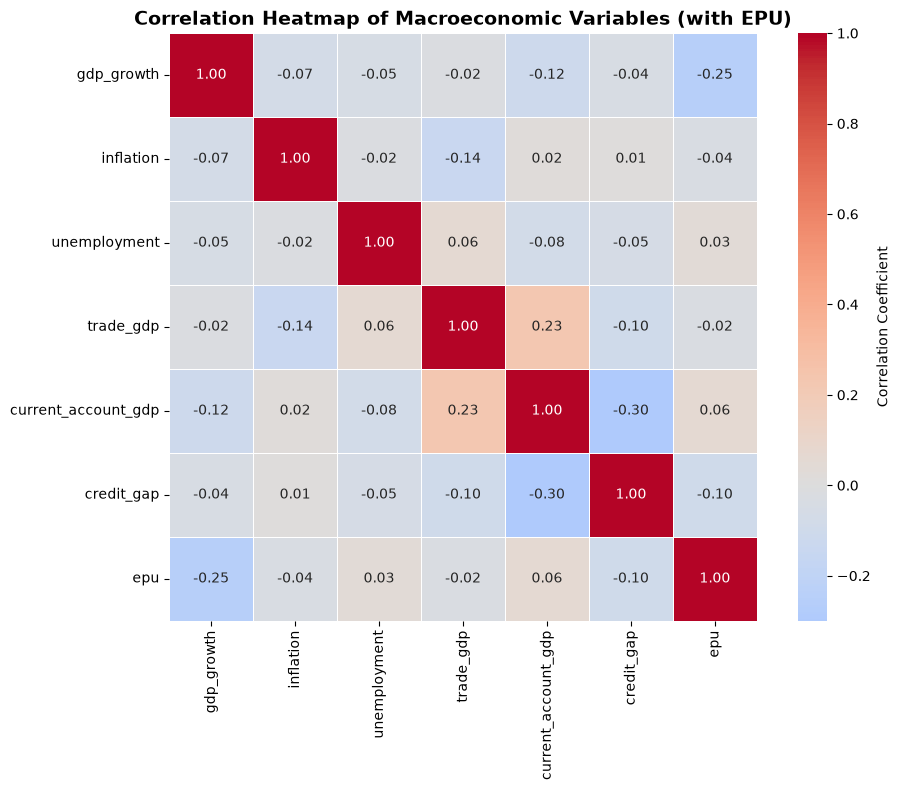


📊 MULTICOLLINEARITY CHECK (VIF) - with EPU:
--------------------------------------------------
            Feature      VIF
       unemployment 6.107150
          trade_gdp 5.012467
                epu 3.379326
         gdp_growth 1.590566
          inflation 1.145357
         credit_gap 1.084742
current_account_gdp 1.077079

Interpretation:
  - VIF > 10: High multicollinearity (consider removing or combining)
  - VIF > 5: Moderate multicollinearity (proceed with caution)
  - VIF < 5: Acceptable multicollinearity

📊 EPU ANALYSIS:
--------------------------------------------------

EPU Statistics by Country:
           mean     std    min     max  count
country                                      
ARG       99.73   59.25  23.33  376.00    168
BRA      150.52   81.40  32.67  460.00    174
CHL      115.70   66.63  30.67  399.33    168
DEU      105.84   30.47  59.67  201.00    105
ESP         NaN     NaN    NaN     NaN      0
GBR      126.14   58.88  39.33  359.67    162
IND       91.92 

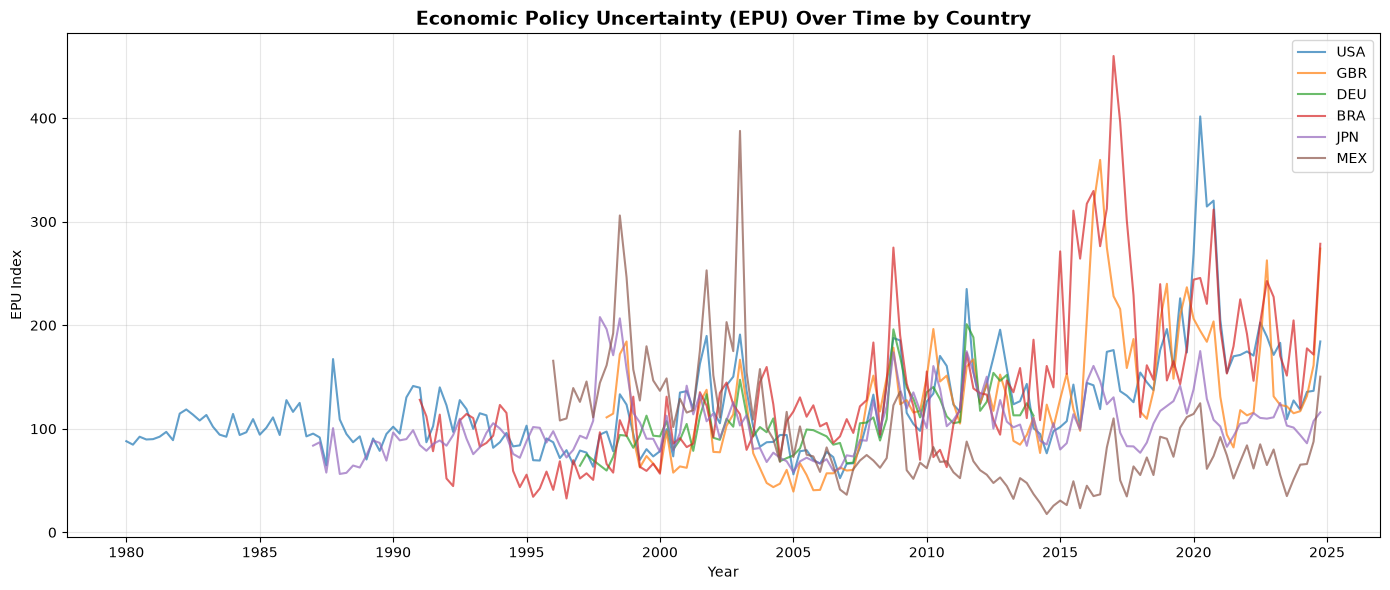


📊 EPU AND CRISIS RELATIONSHIP:
--------------------------------------------------
EPU During Crisis vs Non-Crisis:
              mean    std  count
Non-Crisis  119.68  73.77   1586
Crisis      126.52  52.54    158


/var/folders/9k/87r4y5h92msglbssq662km1h0000gn/T/ipykernel_7605/2461558973.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=inspection_df, x='crisis', y='epu',


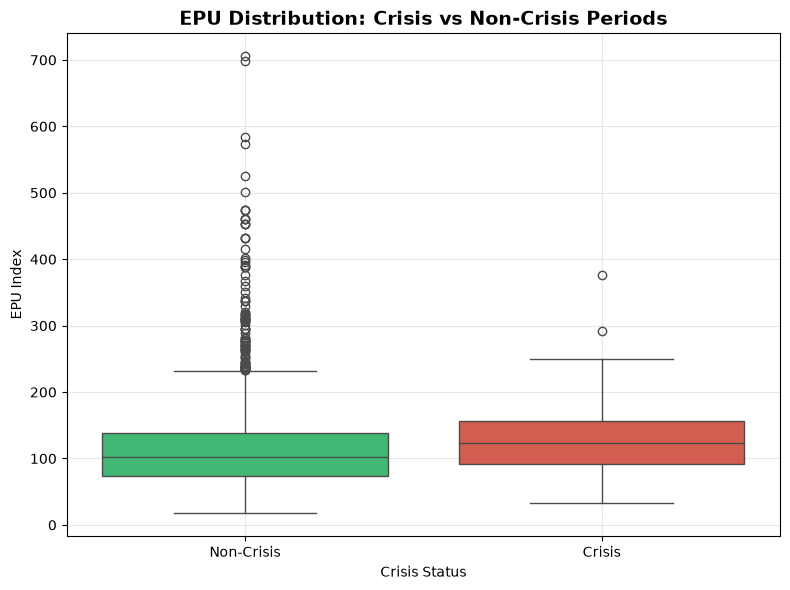


📊 TIME SERIES TRENDS BY COUNTRY (with EPU):
--------------------------------------------------


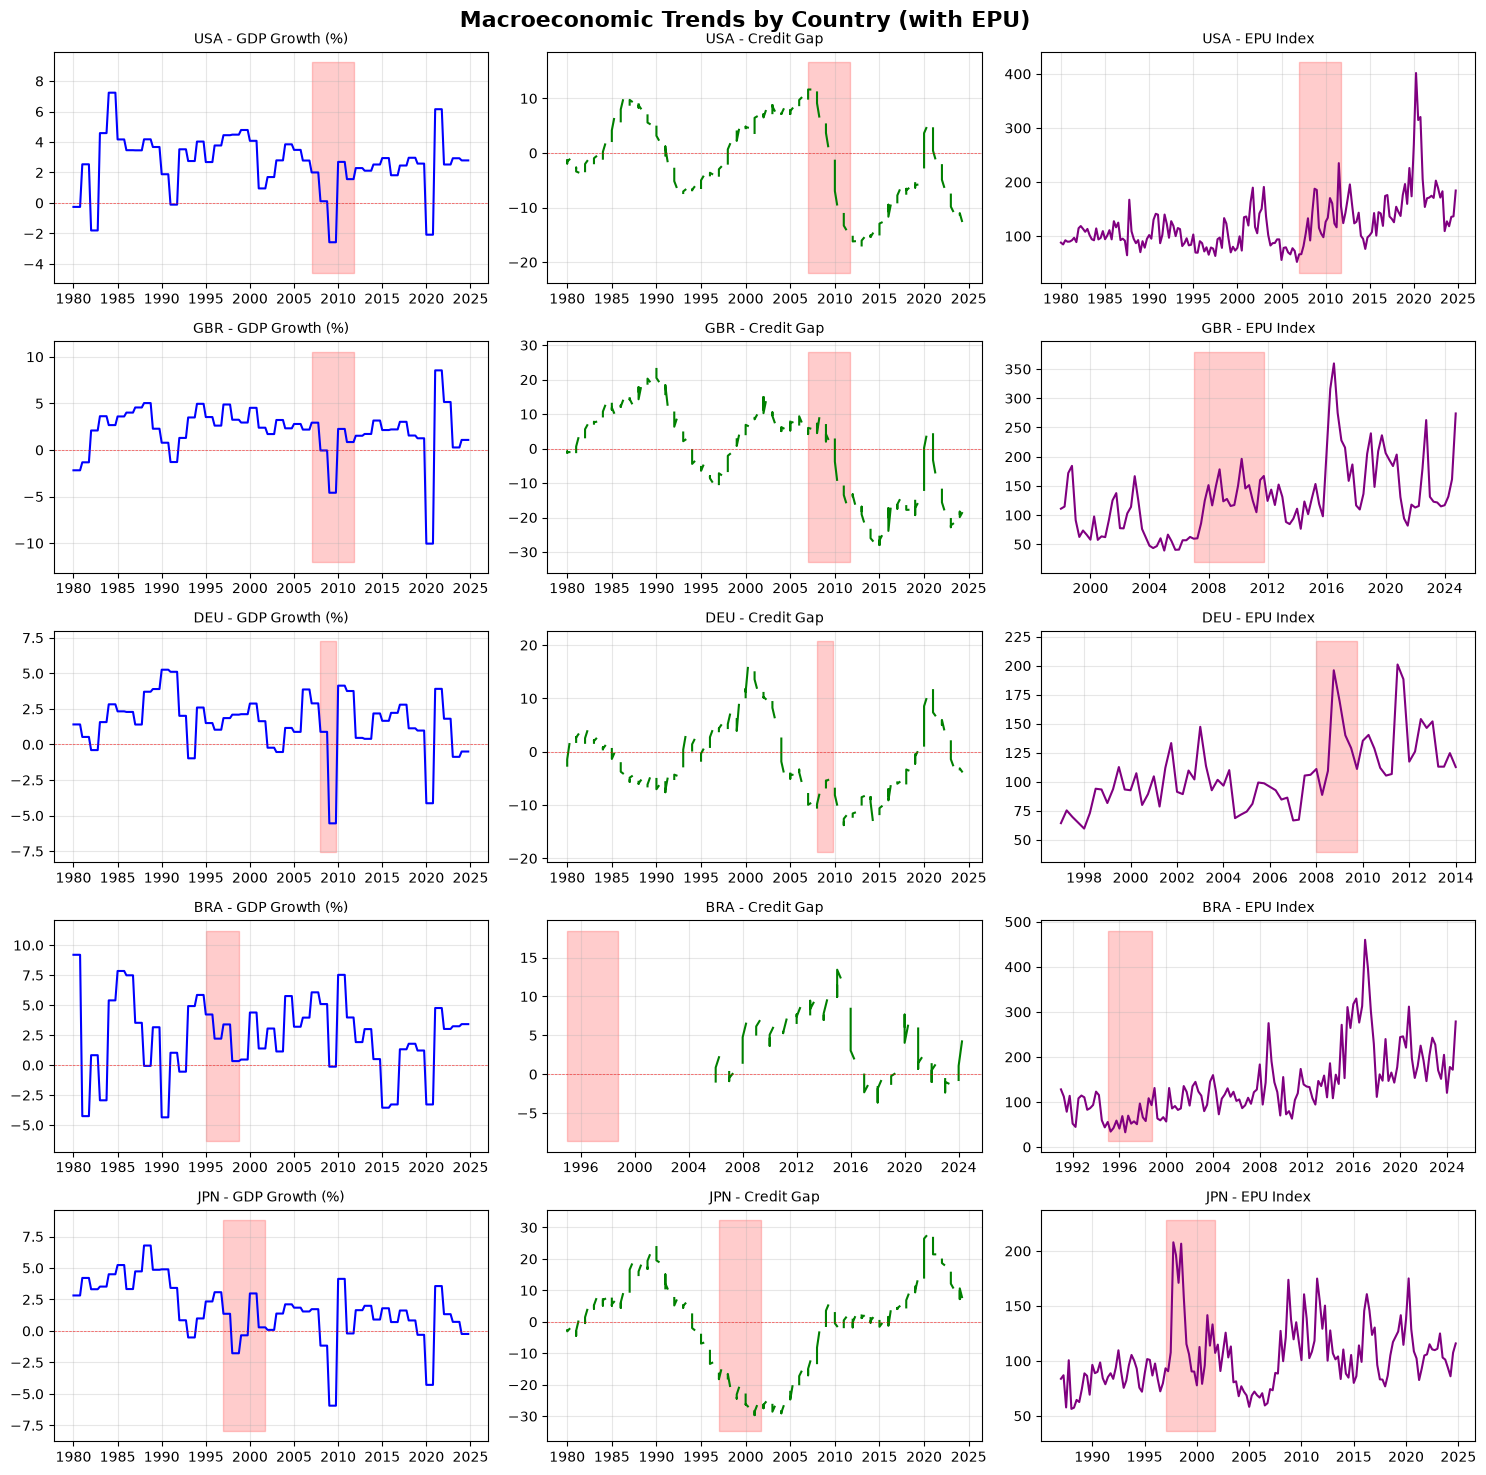


📊 SUMMARY STATISTICS BY COUNTRY (with EPU):
--------------------------------------------------
        gdp_growth                     inflation                          \
              mean   std    min    max      mean     std    min      max   
country                                                                    
ARG           1.78  5.70 -10.89  10.44     86.29   63.37  34.28   219.88   
BRA           2.34  3.21  -4.35   9.20    221.18  578.79   3.20  2947.73   
CHL           4.06  4.03 -11.50  11.50      8.20    7.97   0.35    35.14   
DEU           1.56  2.03  -5.54   5.26      2.27    1.70  -0.13     6.87   
ESP           2.20  2.94 -10.94   6.68      4.54    3.95  -0.50    15.56   
GBR           2.07  2.81 -10.05   8.54      3.76    3.21   0.37    17.97   
IND           5.99  2.58  -5.78   9.69      7.55    2.97   3.33    13.87   
JPN           1.70  2.37  -5.94   6.79      1.06    1.70  -1.35     7.78   
MEX           2.21  3.56  -8.35   9.59     18.74   27.72   2.72   13

In [35]:
# ========================================
# STEP 7: DATA INSPECTION & MULTICOLLINEARITY (with EPU)
# ========================================

import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load the panel with EPU (or use panel_merged if it already has EPU)
# If you're running this after Cell 43, panel_merged already has EPU
inspection_df = panel_merged.copy()

print("=" * 70)
print("DATA INSPECTION: CORRELATION ANALYSIS (with EPU)")
print("=" * 70)

# 1. Correlation Heatmap (INCLUDING EPU)
print("\n📊 CORRELATION HEATMAP (with EPU):")
print("-" * 50)

# Select numeric features for correlation (include EPU now)
feature_cols = ['gdp_growth', 'inflation', 'unemployment', 'trade_gdp', 
                'current_account_gdp', 'credit_gap', 'epu']  # EPU included!

# Calculate correlation matrix
corr_matrix = inspection_df[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Macroeconomic Variables (with EPU)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Multicollinearity Check (VIF) - INCLUDING EPU
print("\n📊 MULTICOLLINEARITY CHECK (VIF) - with EPU:")
print("-" * 50)

# Drop rows with missing values for VIF calculation
vif_data = inspection_df[feature_cols].dropna()

# Calculate VIF for each feature
vif_dict = {}
for i, col in enumerate(feature_cols):
    vif_dict[col] = variance_inflation_factor(vif_data.values, i)

# Display VIF results
vif_df = pd.DataFrame({
    'Feature': list(vif_dict.keys()),
    'VIF': list(vif_dict.values())
}).sort_values('VIF', ascending=False)

print(vif_df.to_string(index=False))
print("\nInterpretation:")
print("  - VIF > 10: High multicollinearity (consider removing or combining)")
print("  - VIF > 5: Moderate multicollinearity (proceed with caution)")
print("  - VIF < 5: Acceptable multicollinearity")

# 3. EPU-Specific Analysis
print("\n📊 EPU ANALYSIS:")
print("-" * 50)

# EPU distribution by country
print("\nEPU Statistics by Country:")
epu_stats = inspection_df.groupby('country')['epu'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
print(epu_stats)

# EPU over time (for major countries)
epu_countries = ['USA', 'GBR', 'DEU', 'BRA', 'JPN', 'MEX']
epu_time = inspection_df[inspection_df['country'].isin(epu_countries)]

plt.figure(figsize=(14, 6))
for country in epu_countries:
    country_data = epu_time[epu_time['country'] == country].sort_values('date')
    plt.plot(country_data['date'], country_data['epu'], 
             linewidth=1.5, label=country, alpha=0.7)

plt.title('Economic Policy Uncertainty (EPU) Over Time by Country', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('EPU Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Correlation between EPU and Crisis
print("\n📊 EPU AND CRISIS RELATIONSHIP:")
print("-" * 50)

# Compare EPU during crisis vs non-crisis periods
epu_crisis_comparison = inspection_df.groupby('crisis')['epu'].agg(['mean', 'std', 'count']).round(2)
epu_crisis_comparison.index = ['Non-Crisis', 'Crisis']
print("EPU During Crisis vs Non-Crisis:")
print(epu_crisis_comparison)

# Boxplot of EPU by crisis status
plt.figure(figsize=(8, 6))
sns.boxplot(data=inspection_df, x='crisis', y='epu', 
            palette=['#2ecc71', '#e74c3c'])
plt.title('EPU Distribution: Crisis vs Non-Crisis Periods', fontsize=14, fontweight='bold')
plt.xlabel('Crisis Status')
plt.ylabel('EPU Index')
plt.xticks([0, 1], ['Non-Crisis', 'Crisis'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Time Series Plots (INCLUDING EPU)
print("\n📊 TIME SERIES TRENDS BY COUNTRY (with EPU):")
print("-" * 50)

# Select a few key countries
countries_to_plot = ['USA', 'GBR', 'DEU', 'BRA', 'JPN']

fig, axes = plt.subplots(len(countries_to_plot), 3, figsize=(15, len(countries_to_plot)*3))
fig.suptitle('Macroeconomic Trends by Country (with EPU)', fontsize=16, fontweight='bold')

for i, country in enumerate(countries_to_plot):
    country_data = inspection_df[inspection_df['country'] == country].sort_values('date')
    
    # GDP Growth
    ax = axes[i, 0]
    ax.plot(country_data['date'], country_data['gdp_growth'], linewidth=1.5, color='blue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.7)
    crisis_periods = country_data[country_data['crisis'] == 1]
    if len(crisis_periods) > 0:
        ax.fill_between(crisis_periods['date'], 
                        country_data['gdp_growth'].min() - 2, 
                        country_data['gdp_growth'].max() + 2, 
                        alpha=0.2, color='red')
    ax.set_title(f'{country} - GDP Growth (%)', fontsize=10)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
    
    # Credit Gap
    ax = axes[i, 1]
    ax.plot(country_data['date'], country_data['credit_gap'], linewidth=1.5, color='green')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.5, alpha=0.7)
    if len(crisis_periods) > 0:
        ax.fill_between(crisis_periods['date'], 
                        country_data['credit_gap'].min() - 5, 
                        country_data['credit_gap'].max() + 5, 
                        alpha=0.2, color='red')
    ax.set_title(f'{country} - Credit Gap', fontsize=10)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
    
    # EPU
    ax = axes[i, 2]
    ax.plot(country_data['date'], country_data['epu'], linewidth=1.5, color='purple')
    if len(crisis_periods) > 0:
        ax.fill_between(crisis_periods['date'], 
                        country_data['epu'].min() - 20, 
                        country_data['epu'].max() + 20, 
                        alpha=0.2, color='red')
    ax.set_title(f'{country} - EPU Index', fontsize=10)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Summary Statistics Table (INCLUDING EPU)
print("\n📊 SUMMARY STATISTICS BY COUNTRY (with EPU):")
print("-" * 50)

summary_stats = inspection_df.groupby('country')[feature_cols].agg(['mean', 'std', 'min', 'max']).round(2)
print(summary_stats)

# 7. Class Balance Check
print("\n📊 CLASS BALANCE (Target Variable):")
print("-" * 50)
crisis_counts = inspection_df['crisis'].value_counts()
crisis_pct = (crisis_counts / len(inspection_df) * 100).round(2)

balance_df = pd.DataFrame({
    'Crisis': ['No (0)', 'Yes (1)'],
    'Count': crisis_counts.values,
    'Percentage': crisis_pct.values
})
print(balance_df.to_string(index=False))

# 8. Feature Availability Check
print("\n📊 FEATURE AVAILABILITY BY COUNTRY:")
print("-" * 50)
availability = inspection_df.groupby('country')[feature_cols].count()
availability_pct = (availability / inspection_df.groupby('country').size() * 100).round(1)
print("Count of non-missing values (and percentage of total):")
print(availability)
print("\nPercentage available:")
print(availability_pct)

print("\n" + "=" * 70)
print("DATA INSPECTION COMPLETE")
print("=" * 70)